# Importar Librerias

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay
from sklearn.preprocessing import LabelEncoder

# Funcion mertricas de clasificacion

In [65]:
def metricas_clasificacion_binaria(y_true, y_pred, y_score, nombre_modelo, etiqueta_calcular ):
    exactitud = accuracy_score(y_true = y_true, y_pred= y_pred)
    presicion = precision_score(y_true = y_true, y_pred= y_pred, pos_label = etiqueta_calcular )
    recall = recall_score(y_true = y_true, y_pred= y_pred, pos_label= etiqueta_calcular)
    f1= f1_score(y_true = y_true, y_pred= y_pred, pos_label= etiqueta_calcular)
    roc_auc = roc_auc_score(y_true= y_true, y_score= y_score)

    return pd.DataFrame(data=[[exactitud, presicion, recall, f1, roc_auc]], columns=[["exactitud", "presicion", "recall", "f1", "roc_auc"]], index= [nombre_modelo]).T

# Datos

In [66]:
df_spam = pd.read_csv(filepath_or_buffer= "spam.csv", encoding= "latin-1")
df_spam.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Separando columnas que vamos a usar

In [67]:
df_spam2 = df_spam[["v1", "v2"]]
df_spam2.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Cambiando nombres a columnas

In [68]:
df_spam2 = df_spam2.rename(columns= {"v1": "etiqueta", "v2": "texto"})
df_spam2.tail(5)

,etiqueta,texto
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


## Contando valores

In [69]:
df_spam2["etiqueta"].value_counts()

etiqueta
ham     4825
spam     747
Name: count, dtype: int64

## Separacion de datos

In [70]:
x= df_spam2["texto"]
y= df_spam2["etiqueta"]

In [71]:
x_entrenamiento, x_validacion, y_entrenamiento, y_validacion = train_test_split(x, y, test_size= 0.3, random_state= 19)

## Codificando etiquetas

In [72]:
codificador = LabelEncoder()
y_entrenamiento = codificador.fit_transform(y_entrenamiento)
y_validacion = codificador.transform(y_validacion)
for codigo, clase in enumerate(codificador.classes_):
    print(f"{codigo} -> {clase}")

0 -> ham
1 -> spam


# Vectorizando datos

In [73]:
vectorizador = CountVectorizer()
x_entrenamiento_vectorizado = vectorizador.fit_transform(x_entrenamiento)
x_validacion_vectorizado = vectorizador.transform(x_validacion)

# Modelado GaussianNB()

In [74]:
modelo_gausiano = GaussianNB()
modelo_gausiano.fit(X= x_entrenamiento_vectorizado.toarray(), y=y_entrenamiento)

,priors,None
,var_smoothing,1e-09


## Realizando predicciones

In [75]:
y_predicciones_gausiano = modelo_gausiano.predict(X= x_validacion_vectorizado.toarray())
y_proba_gausiano = modelo_gausiano.predict_proba(X= x_validacion_vectorizado.toarray())[:, 1]
y_predicciones_gausiano

array([0, 1, 1, ..., 1, 1, 0], shape=(1672,))

## Metricas

In [76]:
metricas_gausiano_ham = metricas_clasificacion_binaria(y_true= y_validacion, y_pred= y_predicciones_gausiano, y_score= y_proba_gausiano, nombre_modelo= "GaussianNB_ham", etiqueta_calcular= 0)
metricas_gausiano_spam = metricas_clasificacion_binaria(y_true= y_validacion, y_pred= y_predicciones_gausiano, y_score= y_proba_gausiano, nombre_modelo= "GaussianNB_spam", etiqueta_calcular= 1)

metricas_gausiano = pd.concat(objs= [metricas_gausiano_ham, metricas_gausiano_spam], axis= 1)
metricas_gausiano

,GaussianNB_ham,GaussianNB_spam
exactitud,0.906100,0.906100
presicion,0.982496,0.625698
recall,0.905965,0.906883
f1,0.942680,0.740496
roc_auc,0.906424,0.906424


In [77]:
reporte_clasificacion_gausiano = classification_report(y_true=y_validacion, y_pred= y_predicciones_gausiano, target_names= codificador.classes_)
print(reporte_clasificacion_gausiano)

              precision    recall  f1-score   support

         ham       0.98      0.91      0.94      1425
        spam       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



In [78]:
"""Es un reporte de clasificacion donde podemos ver de manera idependiente las metricas de cada una de las variables. En el contexto del dataset lo que nos importa es la variable de "spam", donde podemos ver que sus metricas de presicion y f1 son inferiores comparadas con la variable "ham", lo que no lo hace un modelo tan confiable para la deteccion de spam. La poca presicion de "ham" puede deberse a sus pocos datos, siendo solo 247 en la validacion que equivale a el 20% del dataset completo"""

'Es un reporte de clasificacion donde podemos ver de manera idependiente las metricas de cada una de las variables. En el contexto del dataset lo que nos importa es la variable de "spam", donde podemos ver que sus metricas de presicion y f1 son inferiores comparadas con la variable "ham", lo que no lo hace un modelo tan confiable para la deteccion de spam. La poca presicion de "ham" puede deberse a sus pocos datos, siendo solo 247 en la validacion que equivale a el 20% del dataset completo'

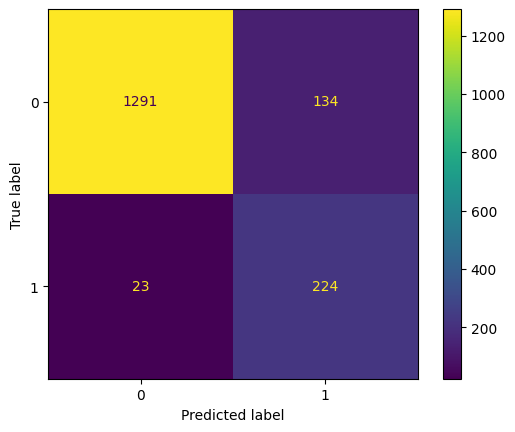

In [79]:
matriz_confusion_gausiano = ConfusionMatrixDisplay.from_predictions(y_pred= y_predicciones_gausiano, y_true= y_validacion)

In [80]:
"""En la matriz de confusion del modelo gausiano podemos observar que presenta un nivel elevado de Falsos positivos, es decir que muchas veces detecta "spam" cuando en realidad era un correo normal, tambien odemos ver, aunque en mejor cantidad, 23 valores falsos negativos, lo que indica que hubieron veces en las que un correo era spam y no lo detecto como tal, en total con lo s datos de prueba cometio 157 errores, lo cual es no es muy buena señal de un modelo confiable"""

'En la matriz de confusion del modelo gausiano podemos observar que presenta un nivel elevado de Falsos positivos, es decir que muchas veces detecta "spam" cuando en realidad era un correo normal, tambien odemos ver, aunque en mejor cantidad, 23 valores falsos negativos, lo que indica que hubieron veces en las que un correo era spam y no lo detecto como tal, en total con lo s datos de prueba cometio 157 errores, lo cual es no es muy buena señal de un modelo confiable'

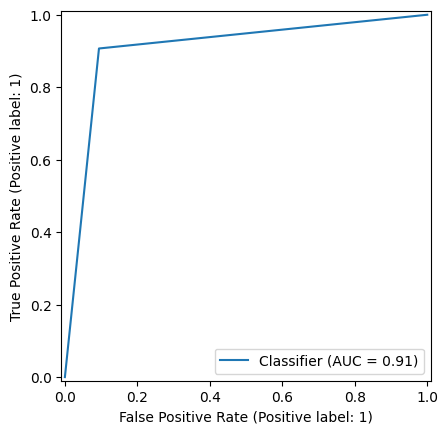

In [81]:
RocCurveDisplay.from_predictions(y_true= y_validacion, y_score= y_proba_gausiano)

# Modelado MultinomialNB

In [82]:
modelo_multinomial = MultinomialNB()
modelo_multinomial.fit(X= x_entrenamiento_vectorizado, y=y_entrenamiento)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [83]:
y_predicciones_multinomial = modelo_multinomial.predict(X= x_validacion_vectorizado)
y_proba_multinomial = modelo_multinomial.predict_proba(X= x_validacion_vectorizado)[:, 1]
y_predicciones_multinomial

array([0, 1, 0, ..., 1, 1, 0], shape=(1672,))

# Metricas

In [84]:
metricas_multinomial_ham = metricas_clasificacion_binaria(y_true= y_validacion , y_pred= y_predicciones_multinomial , y_score= y_proba_multinomial, nombre_modelo= "MultinomialNB_ham", etiqueta_calcular= 0)
metricas_multinomial_spam = metricas_clasificacion_binaria(y_true= y_validacion , y_pred= y_predicciones_multinomial , y_score= y_proba_multinomial, nombre_modelo= "MultinomialNB_spam", etiqueta_calcular= 1)

metricas_multinomial = pd.concat(objs= [metricas_multinomial_ham, metricas_multinomial_spam], axis= 1)
metricas_multinomial

,MultinomialNB_ham,MultinomialNB_spam
exactitud,0.985646,0.985646
presicion,0.988153,0.970464
recall,0.995088,0.931174
f1,0.991608,0.950413
roc_auc,0.989190,0.989190


In [85]:
reporte_clasificacion_multinomial = classification_report(y_true= y_validacion, y_pred= y_predicciones_multinomial, target_names=codificador.classes_)
print(reporte_clasificacion_multinomial)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1425
        spam       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



In [86]:
"""Es un reporte de clasificacion donde podemos ver de manera idependiente las metricas de cada una de las variables. En el contexto del dataset lo que nos importa es la variable de "spam", donde podemos ver que sus metricas de presicion y f1 son solo un poco inferiores comparadas con la variable "ham", lo que lo hace un modelo confiable para la deteccion de spam."""

'Es un reporte de clasificacion donde podemos ver de manera idependiente las metricas de cada una de las variables. En el contexto del dataset lo que nos importa es la variable de "spam", donde podemos ver que sus metricas de presicion y f1 son solo un poco inferiores comparadas con la variable "ham", lo que lo hace un modelo confiable para la deteccion de spam.'

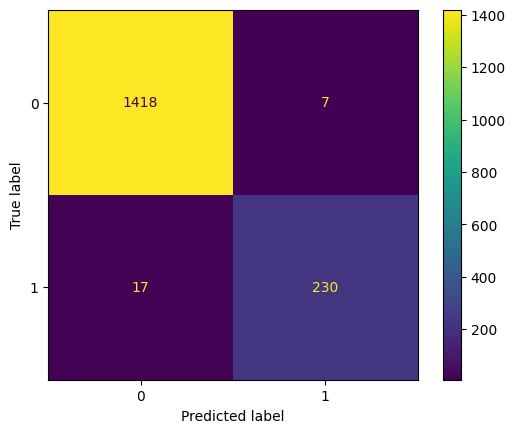

In [87]:
matriz_confusion_multinomial = ConfusionMatrixDisplay.from_predictions(y_true= y_validacion , y_pred= y_predicciones_multinomial)

In [88]:
"""En la matriz de confusion del modelo multinomial podemos observar que presenta un nivel muy bajo de Falsos positivos, es decir que muy pocas veces confuinde un correo normal con uno de spam, tambien podemos ver que presenta 17 valores falsos negativos, lo que indica que hubieron veces en las que un correo era spam y no lo detecto como tal, en total con los datos de prueba cometió 24 errores, lo cual es es muy buena señal de un modelo confiable, a diferencia del modelo gausiano que era mucho menos exacto con sus resultados"""

'En la matriz de confusion del modelo multinomial podemos observar que presenta un nivel muy bajo de Falsos positivos, es decir que muy pocas veces confuinde un correo normal con uno de spam, tambien podemos ver que presenta 17 valores falsos negativos, lo que indica que hubieron veces en las que un correo era spam y no lo detecto como tal, en total con los datos de prueba cometió 24 errores, lo cual es es muy buena señal de un modelo confiable, a diferencia del modelo gausiano que era mucho menos exacto con sus resultados'

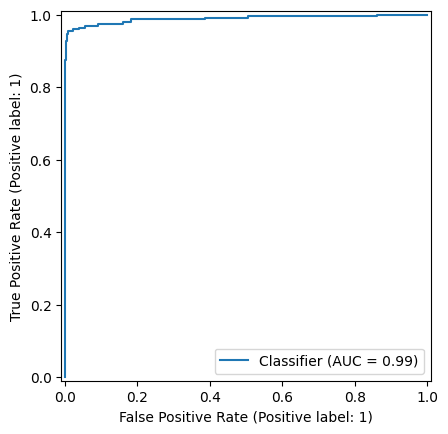

In [89]:
RocCurveDisplay.from_predictions(y_true= y_validacion, y_score= y_proba_multinomial)

# Comparativa de metricas entre modelos

In [90]:
comparativa_metricas = pd.concat(objs=[metricas_gausiano, metricas_multinomial], axis= 1)
comparativa_metricas

,GaussianNB_ham,GaussianNB_spam,MultinomialNB_ham,MultinomialNB_spam
exactitud,0.906100,0.906100,0.985646,0.985646
presicion,0.982496,0.625698,0.988153,0.970464
recall,0.905965,0.906883,0.995088,0.931174
f1,0.942680,0.740496,0.991608,0.950413
roc_auc,0.906424,0.906424,0.989190,0.989190


In [91]:
comparativa_metricas_spam = pd.concat(objs= [metricas_gausiano_spam, metricas_multinomial_spam], axis= 1)
comparativa_metricas_spam

,GaussianNB_spam,MultinomialNB_spam
exactitud,0.906100,0.985646
presicion,0.625698,0.970464
recall,0.906883,0.931174
f1,0.740496,0.950413
roc_auc,0.906424,0.989190


In [92]:
print("Modelo Gausiano > modelo Multinomial:")
print(f" Exactitud: {comparativa_metricas_spam.iloc[0, 0] > comparativa_metricas_spam.iloc[0, 1]}")
print(f" Presicion: {comparativa_metricas_spam.iloc[1, 0] > comparativa_metricas_spam.iloc[1, 1]}")
print(f" Recall: {comparativa_metricas_spam.iloc[2, 0] > comparativa_metricas_spam.iloc[2, 1]}")
print(f" F1 score: {comparativa_metricas_spam.iloc[3, 0] > comparativa_metricas_spam.iloc[3, 1]}")
print(f" ROC_AUC: {comparativa_metricas_spam.iloc[4, 0] > comparativa_metricas_spam.iloc[4, 1]}")

Modelo Gausiano > modelo Multinomial:
 Exactitud: False
 Presicion: False
 Recall: False
 F1 score: False
 ROC_AUC: False


In [93]:
"""Podemos observar que en todas las metricas el modelo Gausiano resulto ser inferior al modelo multinomial en el contexto del dataset"""

'Podemos observar que en todas las metricas el modelo Gausiano resulto ser inferior al modelo multinomial en el contexto del dataset'